# Optimum Filter Tutorial

This tutorial uses **`OptimumFilter.py` (new module)** only.

What is needed to register an OF object?
1. `template` : 1D pulse template (length `N`)
2. `noise_psd` : one-sided PSD with length `N//2 + 1`
3. `sampling_frequency` : sample rate in Hz

After registration, we cover:
- Short trace fitting with `fit` and `fit_with_shift`
- Why the so-called "filtered trace" is actually a **matched-filter correlation response** across delay
- Amplitude trace and chi-square trace vs delay
- Long-trace sliding fit amplitude and chi-square

In [57]:
from __future__ import annotations

import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft, ifft

BASE_DIR = Path.cwd()
SAMPLE_DIR = BASE_DIR / 'samples'
TEMPLATE_DIR = BASE_DIR / 'templates'

SHORT_SAMPLE_PATH = SAMPLE_DIR / 'uv_shift_32768.npy'
LONG_SAMPLE_PATH = SAMPLE_DIR / 'uv_noisy_80000.npy'
DEFAULT_TEMPLATE_PATH = TEMPLATE_DIR / 'UV_template.npy'
DEFAULT_PSD_PATH = TEMPLATE_DIR / 'noise_psd_xray.npy'

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

FS = 3906250

print('Notebook dir:', BASE_DIR)
print('Sample dir  :', SAMPLE_DIR)
print('Template dir:', TEMPLATE_DIR)
print('Short trace :', SHORT_SAMPLE_PATH)
print('Long trace  :', LONG_SAMPLE_PATH)
print('Template    :', DEFAULT_TEMPLATE_PATH)
print('Noise PSD   :', DEFAULT_PSD_PATH)


Notebook dir: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial
Sample dir  : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples
Template dir: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates
Short trace : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_shift_32768.npy
Long trace  : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_80000.npy
Template    : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates/UV_template.npy
Noise PSD   : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates/noise_psd_xray.npy


Template source: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/templates/UV_template.npy
Noise PSD source: estimated from long trace (uv_noisy_80000.npy)
Template length N: 32768
Noise PSD length: 16385
Sampling frequency [Hz]: 3906250


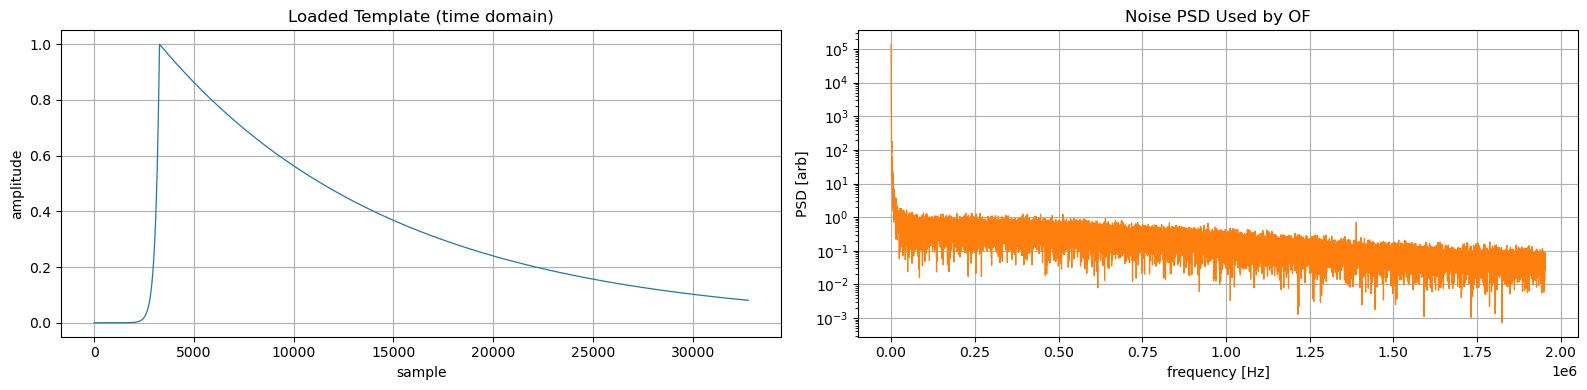

In [58]:
def to_time_template(raw_template: np.ndarray, target_len_hint: int | None):
    if raw_template.ndim == 1:
        return np.asarray(raw_template, dtype=np.float64)

    if raw_template.ndim != 2:
        raise ValueError(f'Template ndim not supported: {raw_template.ndim}')

    if raw_template.shape[0] == 2:
        one_sided = np.asarray(raw_template[1], dtype=np.float64)
    elif raw_template.shape[1] == 2:
        one_sided = np.asarray(raw_template[:, 1], dtype=np.float64)
    else:
        raise ValueError(f'2D template shape not supported: {raw_template.shape}')

    inferred_len = 2 * (one_sided.size - 1)
    target_len = target_len_hint if target_len_hint is not None else inferred_len
    if target_len // 2 + 1 != one_sided.size:
        raise ValueError(
            f'Cannot map one-sided template length {one_sided.size} to target length {target_len}'
        )

    return np.fft.irfft(one_sided, n=target_len).astype(np.float64)


def estimate_psd_from_trace(trace: np.ndarray, n: int):
    if trace.size < n:
        raise ValueError(f'Trace length {trace.size} is smaller than template length {n}')

    nseg = trace.size // n
    blocks = trace[:nseg * n].reshape(nseg, n)
    blocks_fft = np.fft.rfft(blocks, axis=1) / FS

    # Use median periodogram across blocks for a stable deterministic PSD estimate.
    psd = np.median(np.abs(blocks_fft) ** 2 * FS, axis=0)
    psd = np.asarray(psd, dtype=np.float64)

    tiny = np.finfo(np.float64).tiny
    psd = np.maximum(psd, tiny)
    if psd.size > 1:
        psd[0] = max(psd[0], psd[1])
    return psd


if not DEFAULT_TEMPLATE_PATH.exists():
    raise FileNotFoundError(f'Missing template file: {DEFAULT_TEMPLATE_PATH}')

short_len_hint = int(np.load(SHORT_SAMPLE_PATH).size) if SHORT_SAMPLE_PATH.exists() else None
raw_template = np.load(DEFAULT_TEMPLATE_PATH).astype(np.float64)
template = to_time_template(raw_template, short_len_hint)
N = template.size
expected_psd_len = N // 2 + 1

if DEFAULT_PSD_PATH.exists():
    raw_psd = np.load(DEFAULT_PSD_PATH).astype(np.float64)
    if raw_psd.ndim == 1:
        noise_psd = raw_psd
    elif raw_psd.ndim == 2 and raw_psd.shape[0] == 2:
        noise_psd = raw_psd[1]
    elif raw_psd.ndim == 2 and raw_psd.shape[1] == 2:
        noise_psd = raw_psd[:, 1]
    else:
        raise ValueError(f'PSD shape not supported: {raw_psd.shape}')
    psd_source = str(DEFAULT_PSD_PATH)
elif LONG_SAMPLE_PATH.exists():
    long_trace_for_psd = np.load(LONG_SAMPLE_PATH).astype(np.float64)
    noise_psd = estimate_psd_from_trace(long_trace_for_psd, N)
    psd_source = f'estimated from long trace ({LONG_SAMPLE_PATH.name})'
elif SHORT_SAMPLE_PATH.exists():
    short_trace_for_psd = np.load(SHORT_SAMPLE_PATH).astype(np.float64)
    if short_trace_for_psd.size != N:
        raise ValueError(
            f'Short sample length {short_trace_for_psd.size} does not match template length {N}'
        )
    noise_psd = estimate_psd_from_trace(short_trace_for_psd, N)
    psd_source = f'estimated from short trace ({SHORT_SAMPLE_PATH.name})'
else:
    raise FileNotFoundError(
        f'Missing PSD file ({DEFAULT_PSD_PATH}) and no sample trace available for deterministic PSD estimation.'
    )

noise_psd = np.asarray(noise_psd, dtype=np.float64)
if noise_psd.size != expected_psd_len:
    raise ValueError(f'Noise PSD length {noise_psd.size} does not match expected {expected_psd_len}')

tiny = np.finfo(np.float64).tiny
noise_psd = np.maximum(noise_psd, tiny)
if noise_psd.size > 1:
    noise_psd[0] = max(noise_psd[0], noise_psd[1])

of_mod = importlib.reload(importlib.import_module('OptimumFilter'))
of = of_mod.OptimumFilter(template, noise_psd, FS)

print('Template source:', DEFAULT_TEMPLATE_PATH)
print('Noise PSD source:', psd_source)
print('Template length N:', N)
print('Noise PSD length:', noise_psd.size)
print('Sampling frequency [Hz]:', FS)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(np.arange(N), template, lw=0.9, color='tab:blue')
axes[0].set_title('Loaded Template (time domain)')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('amplitude')

freq = np.fft.rfftfreq(N, d=1.0 / FS)
axes[1].plot(freq, noise_psd, lw=0.9, color='tab:orange')
axes[1].set_yscale('log')
axes[1].set_title('Noise PSD Used by OF')
axes[1].set_xlabel('frequency [Hz]')
axes[1].set_ylabel('PSD [arb]')

plt.tight_layout()
plt.show()


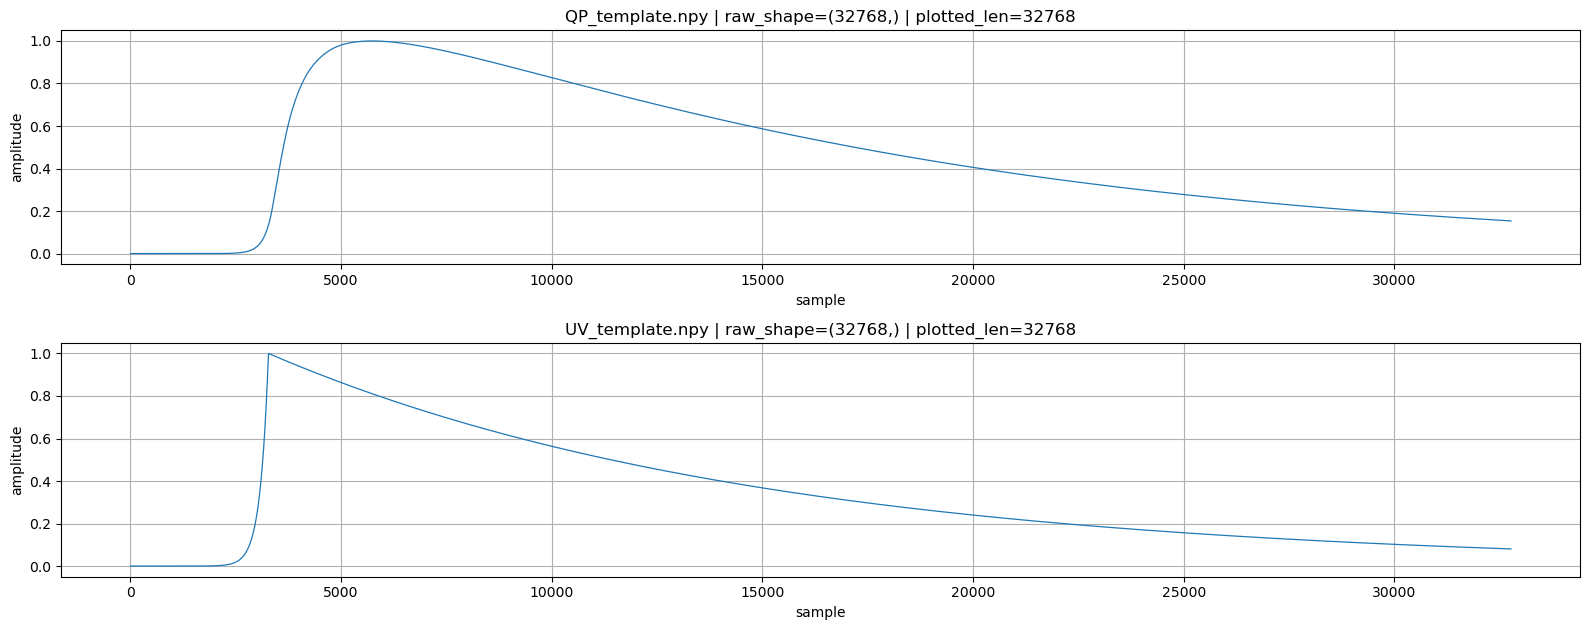

In [59]:
template_files = sorted(TEMPLATE_DIR.glob('*.npy'))
if not template_files:
    print('No template files found under', TEMPLATE_DIR)
else:
    fig, axes = plt.subplots(len(template_files), 1, figsize=(16, 3.2 * len(template_files)))
    if len(template_files) == 1:
        axes = [axes]

    for ax, template_path in zip(axes, template_files):
        raw = np.load(template_path).astype(np.float64)
        try:
            tpl = to_time_template(raw, N)
            ax.plot(np.arange(tpl.size), tpl, lw=0.9)
            ax.set_title(f'{template_path.name} | raw_shape={raw.shape} | plotted_len={tpl.size}')
            ax.set_xlabel('sample')
            ax.set_ylabel('amplitude')
        except Exception as exc:
            ax.text(0.02, 0.5, f'{template_path.name}\nplot skipped: {exc}', transform=ax.transAxes, va='center')
            ax.set_axis_off()

    plt.tight_layout()
    plt.show()


## Short Trace: `fit` and `fit_with_shift`

For a short trace (same length as template):
- `fit(trace)` gives amplitude/chisq at **zero-delay phase convention**
- `fit_with_shift(trace)` searches delay and returns best amplitude, chisq, and `t0`

In [60]:
allowed_shift = (-16384, 16384)

if not SHORT_SAMPLE_PATH.exists():
    raise FileNotFoundError(f'Missing short trace sample: {SHORT_SAMPLE_PATH}')

trace_short = np.load(SHORT_SAMPLE_PATH).astype(np.float64)
if trace_short.size != N:
    raise ValueError(f'Short sample length {trace_short.size} does not match template length {N}')

print('Loaded short trace sample:', SHORT_SAMPLE_PATH)

amp_fit, chisq_fit = of.fit(trace_short)
amp_shift, chisq_shift, t0_shift = of.fit_with_shift(trace_short, allowed_shift_range=allowed_shift)

print('fit()                     : amp =', amp_fit, ', chisq =', chisq_fit)
print('fit_with_shift()          : amp =', amp_shift, ', chisq =', chisq_shift, ', t0 =', t0_shift)


Loaded short trace sample: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_shift_32768.npy
fit()                     : amp = 0.7745655051853981 , chisq = 9.64538850884398e-05
fit_with_shift()          : amp = 43.42644781254074 , chisq = 9.634239299743576e-05 , t0 = 12002


In [61]:
def best_shifted_model(template: np.ndarray, amp: float, t0: int, trace: np.ndarray):
    """
    Build a shifted template waveform for plotting.

    fit_with_shift returns t0 as delay index convention; for visualization,
    evaluate both sign conventions and keep the lower MSE overlay.
    """
    model_pos = amp * np.roll(template, int(t0))
    model_neg = amp * np.roll(template, int(-t0))

    mse_pos = float(np.mean((trace - model_pos) ** 2))
    mse_neg = float(np.mean((trace - model_neg) ** 2))

    if mse_pos <= mse_neg:
        return model_pos, int(t0), 'roll(+t0)', mse_pos

    return model_neg, int(-t0), 'roll(-t0)', mse_neg


def fit_with_shift_traces(of_instance, trace: np.ndarray, allowed_shift_range=None):
    """Reproduce the internal delay-domain traces used by fit_with_shift."""
    n = of_instance._length
    fs = of_instance._sampling_frequency

    trace_fft = fft(trace) / fs
    amp_trace = np.real(ifft(of_instance._filter_kernel * trace_fft)) * fs

    chi0 = np.real((trace_fft.conj() * trace_fft / of_instance._noise_psd_unfolded).sum()) * fs / n
    chi_trace = chi0 - (amp_trace ** 2) * of_instance._kernel_normalization
    reduced_chi_trace = chi_trace / (n - 3)

    if allowed_shift_range is None:
        allowed_idx = np.arange(n)
    else:
        allowed_idx = np.concatenate((
            np.arange(n + allowed_shift_range[0], n),
            np.arange(allowed_shift_range[1] + 1),
        ))

    best_idx = int(allowed_idx[np.argmin(chi_trace[allowed_idx])])
    best_t0 = best_idx if best_idx < n // 2 else best_idx - n

    return {
        'amp_trace': amp_trace,
        'chi_trace': chi_trace,
        'reduced_chi_trace': reduced_chi_trace,
        'allowed_idx': allowed_idx,
        'best_idx': best_idx,
        'best_t0': int(best_t0),
        'best_amp': float(amp_trace[best_idx]),
        'best_red_chi': float(reduced_chi_trace[best_idx]),
    }


## Amplitude Trace and Chi-square Trace vs Delay

`trace_filtered_td = ifft(filter_kernel * trace_fft)` is often called a "filtered trace", but in OF context it is better interpreted as a **matched-filter response (correlation-like score vs delay)**.

- Peaks in amplitude trace indicate delay hypotheses that match the template best.
- Chi-square trace is computed from that amplitude response. Lower is better.
- For waveform overlays, always verify the `t0` sign convention against residuals; plotting with the wrong roll sign can look visibly wrong even if fit statistics are correct.


In [62]:
trace_metrics = fit_with_shift_traces(of, trace_short, allowed_shift)
amp_trace = trace_metrics['amp_trace']
chi_trace = trace_metrics['chi_trace']
reduced_chi_trace = trace_metrics['reduced_chi_trace']
allowed_idx = trace_metrics['allowed_idx']
best_idx = trace_metrics['best_idx']
best_t0 = trace_metrics['best_t0']
best_amp = trace_metrics['best_amp']
best_red_chi = trace_metrics['best_red_chi']

print('Manual best t0 from traces     :', best_t0)
print('Manual best amp from traces    :', best_amp)
print('Manual best reduced chisq      :', best_red_chi)
print('fit_with_shift t0              :', t0_shift)
print('fit_with_shift amp             :', amp_shift)
print('fit_with_shift reduced chisq   :', chisq_shift)

print('amp agreement:', abs(best_amp - amp_shift))
print('chisq agreement:', abs(best_red_chi - chisq_shift))
print('t0 agreement:', abs(best_t0 - t0_shift))

Manual best t0 from traces     : 12002
Manual best amp from traces    : 43.42644781254074
Manual best reduced chisq      : 9.634239299743576e-05
fit_with_shift t0              : 12002
fit_with_shift amp             : 43.42644781254074
fit_with_shift reduced chisq   : 9.634239299743576e-05
amp agreement: 0.0
chisq agreement: 0.0
t0 agreement: 0


fit_with_shift plot convention: roll(+t0) | effective shift for overlay = 12002


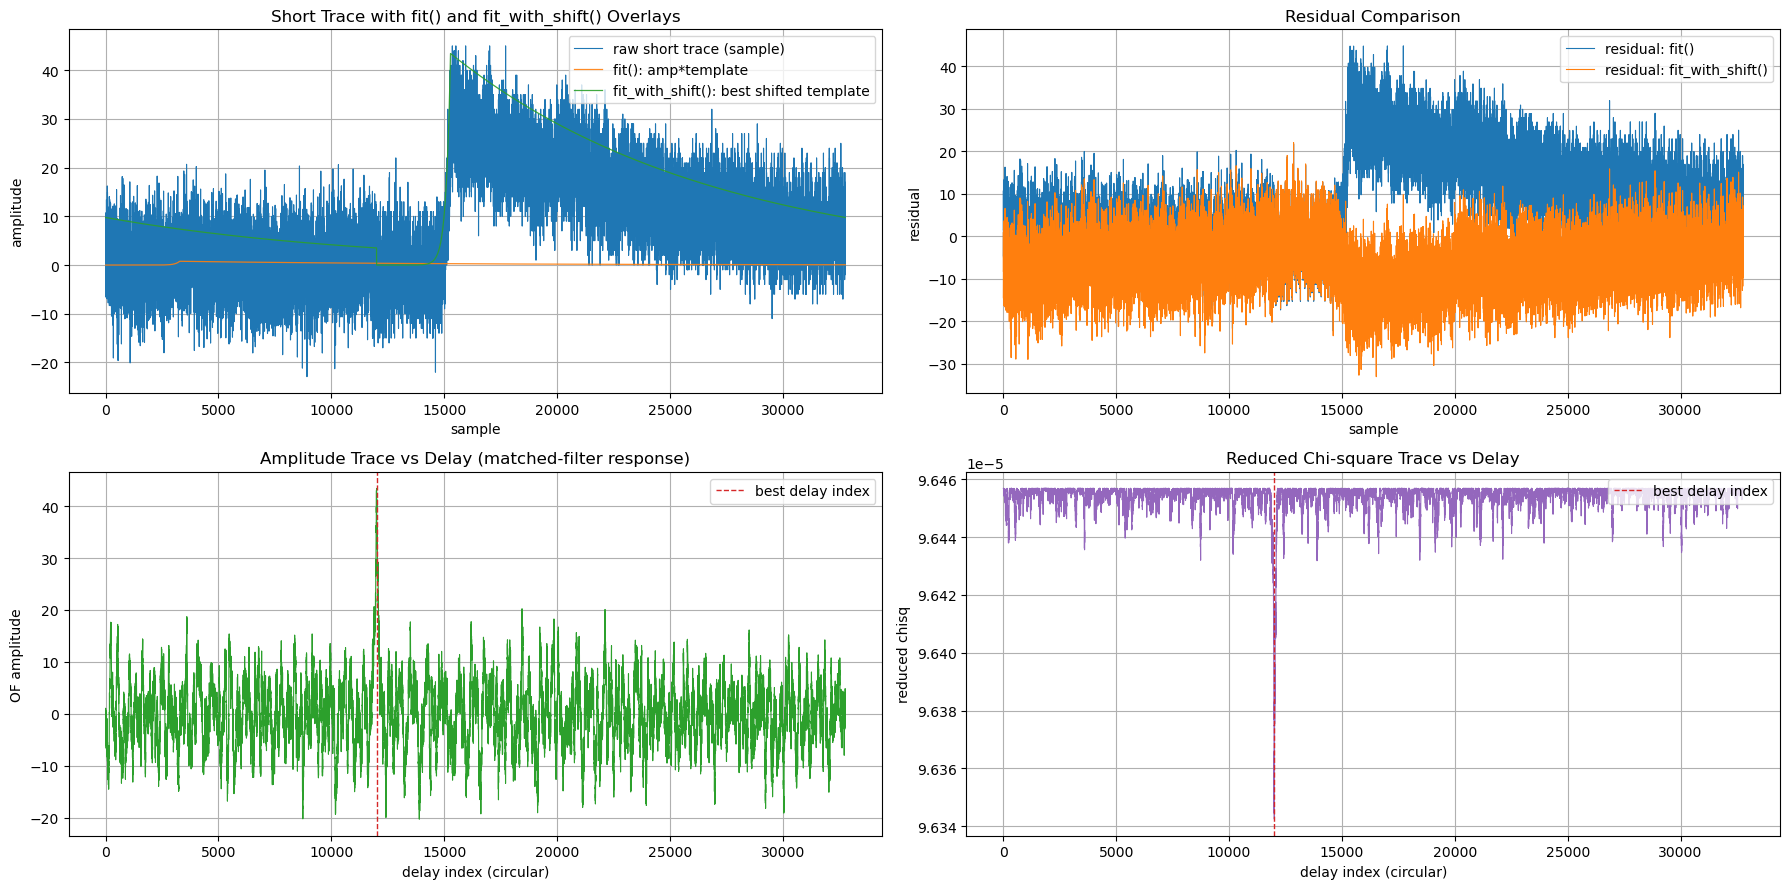

In [63]:
x = np.arange(N)
fit_zero = amp_fit * template
fit_shifted, shift_for_plot, shift_rule, mse_shift = best_shifted_model(template, amp_shift, t0_shift, trace_short)

print('fit_with_shift plot convention:', shift_rule, '| effective shift for overlay =', shift_for_plot)

fig, axes = plt.subplots(2, 2, figsize=(18, 9))

axes[0, 0].plot(x, trace_short, lw=0.8, label='raw short trace (sample)')
axes[0, 0].plot(x, fit_zero, lw=0.9, label='fit(): amp*template', alpha=0.9)
axes[0, 0].plot(x, fit_shifted, lw=0.9, label='fit_with_shift(): best shifted template', alpha=0.9)
axes[0, 0].set_title('Short Trace with fit() and fit_with_shift() Overlays')
axes[0, 0].set_xlabel('sample')
axes[0, 0].set_ylabel('amplitude')
axes[0, 0].legend(loc='upper right')

axes[0, 1].plot(x, trace_short - fit_zero, lw=0.8, label='residual: fit()')
axes[0, 1].plot(x, trace_short - fit_shifted, lw=0.8, label='residual: fit_with_shift()')
axes[0, 1].set_title('Residual Comparison')
axes[0, 1].set_xlabel('sample')
axes[0, 1].set_ylabel('residual')
axes[0, 1].legend(loc='upper right')

axes[1, 0].plot(x, amp_trace, lw=0.8, color='tab:green')
axes[1, 0].axvline(best_idx, color='tab:red', ls='--', lw=1.0, label='best delay index')
axes[1, 0].set_title('Amplitude Trace vs Delay (matched-filter response)')
axes[1, 0].set_xlabel('delay index (circular)')
axes[1, 0].set_ylabel('OF amplitude')
axes[1, 0].legend(loc='upper right')

axes[1, 1].plot(x, reduced_chi_trace, lw=0.8, color='tab:purple')
axes[1, 1].axvline(best_idx, color='tab:red', ls='--', lw=1.0, label='best delay index')
axes[1, 1].set_title('Reduced Chi-square Trace vs Delay')
axes[1, 1].set_xlabel('delay index (circular)')
axes[1, 1].set_ylabel('reduced chisq')
axes[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## Template Mismatch (Why Chi-square Can Inflate)

`OptimumFilter` assumes the pulse shape in data matches the registered template. If the true pulse shape differs:

- Matched-filter response weakens (lower recovered amplitude / less sharp peak)
- Residual structure remains after fitting
- Reduced chi-square tends to increase

So a high reduced chi-square can indicate model mismatch (template or PSD), not only random noise fluctuation.

Below, besides reporting amplitude/chisq/t0, we also plot each best-fit waveform overlay and residual to inspect mismatch directly.

For this mismatch demo we intentionally switch to `samples/uv_noisy_32768.npy` so it uses the noisy short trace rather than the shifted example above, and we also expose the `fit_with_shift` amplitude / chi-square traces versus delay.


Loaded mismatch trace: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_32768.npy
Using UV template  : amp = 46.8903965563702 , chisq = 9.29623840739714e-05 , t0 = 2
Using alt template : amp = 49.2195177068656 , chisq = 9.302921593822387e-05 , t0 = 2
chisq ratio (alt/uv): 1.0007189129766647
UV overlay convention : roll(+t0) | effective shift = 2 | MSE = 87.2946436119119
Alt overlay convention: roll(-t0) | effective shift = -2 | MSE = 278.86177240976303


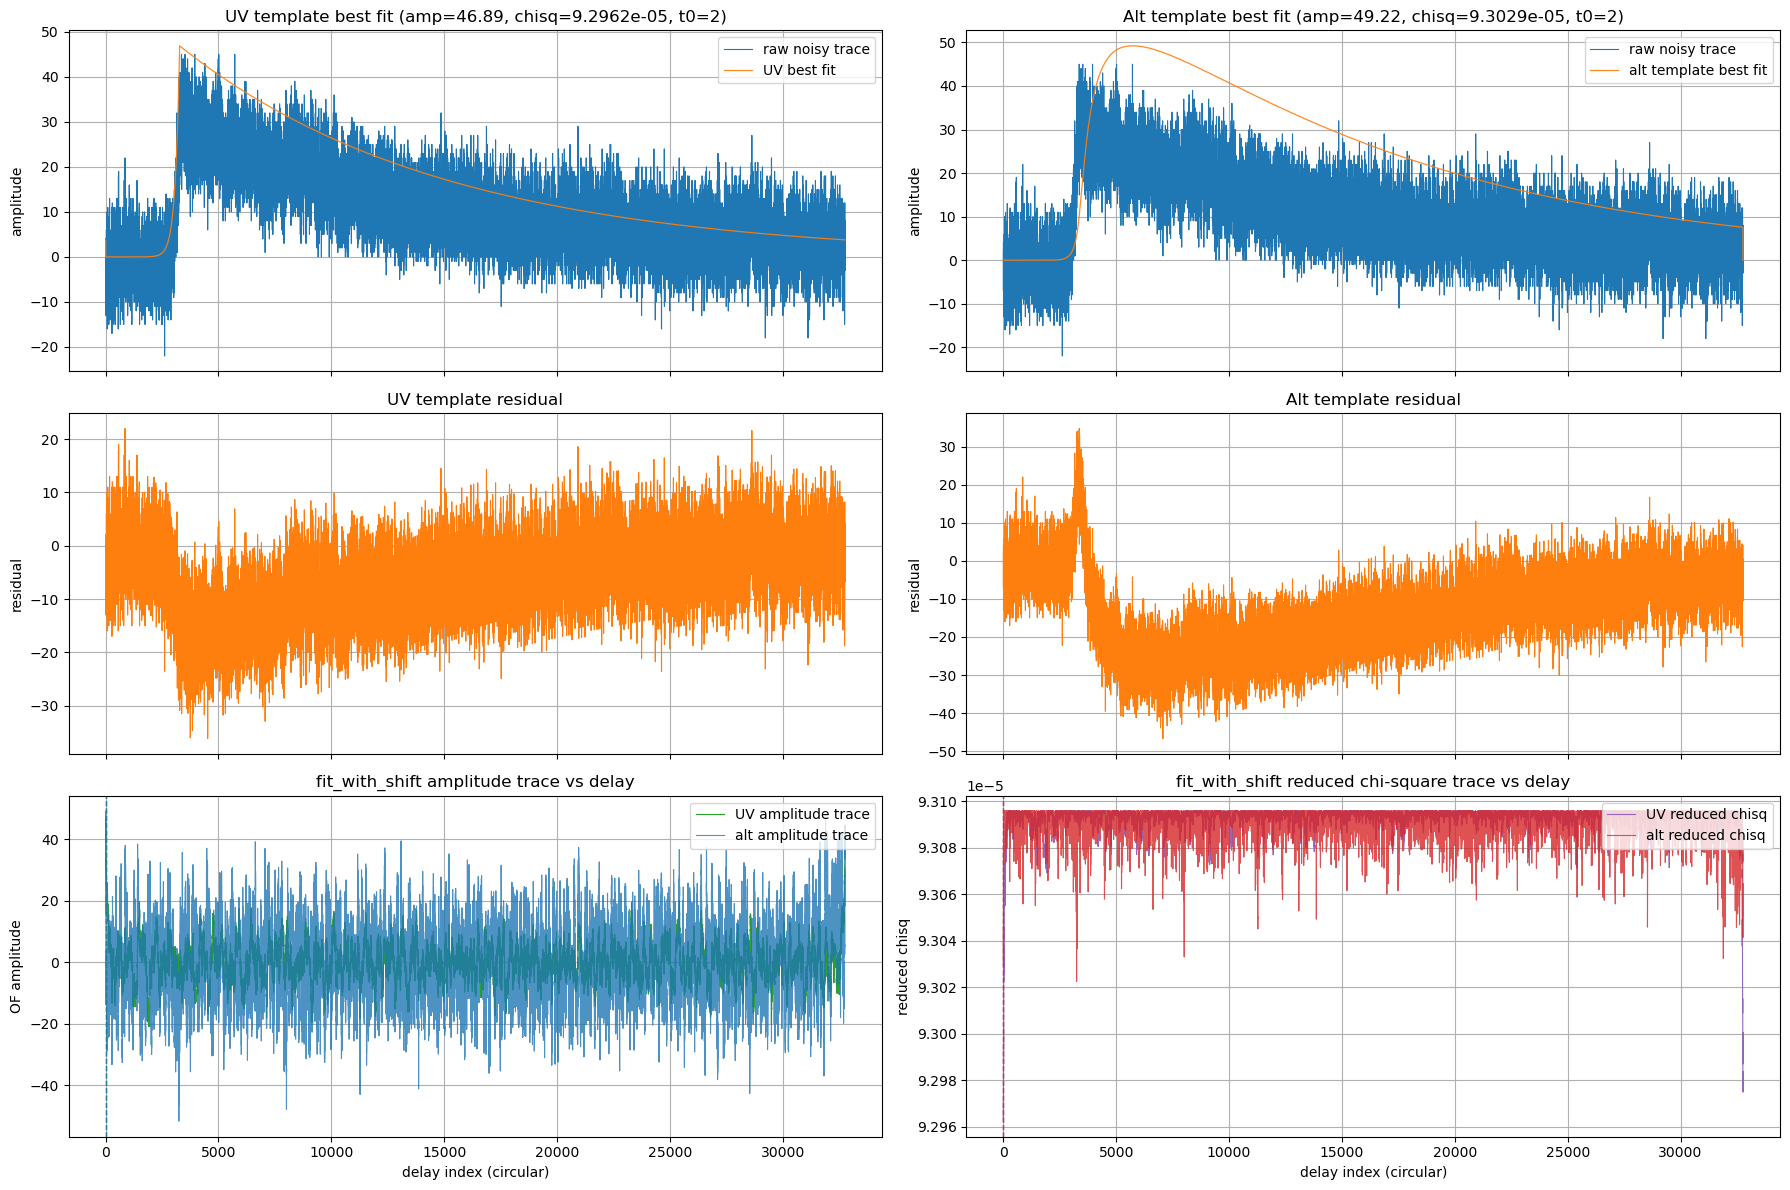

In [64]:
mismatch_template_path = TEMPLATE_DIR / 'QP_template.npy'
mismatch_sample_path = SAMPLE_DIR / 'uv_noisy_32768.npy'
allowed_mismatch = (-64, 64)
if mismatch_template_path.exists() and mismatch_sample_path.exists():
    template_mismatch = np.load(mismatch_template_path).astype(np.float64)
    trace_mismatch = np.load(mismatch_sample_path).astype(np.float64)
    if template_mismatch.size != N:
        print('Template mismatch demo skipped: size mismatch', template_mismatch.size, '!=', N)
    elif trace_mismatch.size != N:
        print('Template mismatch demo skipped: trace size mismatch', trace_mismatch.size, '!=', N)
    else:
        of_mismatch = of_mod.OptimumFilter(template_mismatch, noise_psd, FS)

        uv_metrics = fit_with_shift_traces(of, trace_mismatch, allowed_mismatch)
        mis_metrics = fit_with_shift_traces(of_mismatch, trace_mismatch, allowed_mismatch)

        amp_uv, chi_uv, t_uv = of.fit_with_shift(trace_mismatch, allowed_shift_range=allowed_mismatch)
        amp_mis, chi_mis, t_mis = of_mismatch.fit_with_shift(trace_mismatch, allowed_shift_range=allowed_mismatch)

        fit_uv, shift_uv_plot, rule_uv, mse_uv = best_shifted_model(template, amp_uv, t_uv, trace_mismatch)
        fit_mis, shift_mis_plot, rule_mis, mse_mis = best_shifted_model(template_mismatch, amp_mis, t_mis, trace_mismatch)

        print('Loaded mismatch trace:', mismatch_sample_path)
        print('Using UV template  : amp =', amp_uv, ', chisq =', chi_uv, ', t0 =', t_uv)
        print('Using alt template : amp =', amp_mis, ', chisq =', chi_mis, ', t0 =', t_mis)
        print('chisq ratio (alt/uv):', (chi_mis / chi_uv) if chi_uv != 0 else np.nan)
        print('UV overlay convention :', rule_uv, '| effective shift =', shift_uv_plot, '| MSE =', mse_uv)
        print('Alt overlay convention:', rule_mis, '| effective shift =', shift_mis_plot, '| MSE =', mse_mis)

        x = np.arange(N)
        fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex='col')

        axes[0, 0].plot(x, trace_mismatch, lw=0.8, label='raw noisy trace')
        axes[0, 0].plot(x, fit_uv, lw=0.9, label='UV best fit', alpha=0.9)
        axes[0, 0].set_title(f'UV template best fit (amp={amp_uv:.5g}, chisq={chi_uv:.5g}, t0={t_uv})')
        axes[0, 0].set_ylabel('amplitude')
        axes[0, 0].legend(loc='upper right')

        axes[0, 1].plot(x, trace_mismatch, lw=0.8, label='raw noisy trace')
        axes[0, 1].plot(x, fit_mis, lw=0.9, label='alt template best fit', alpha=0.9)
        axes[0, 1].set_title(f'Alt template best fit (amp={amp_mis:.5g}, chisq={chi_mis:.5g}, t0={t_mis})')
        axes[0, 1].set_ylabel('amplitude')
        axes[0, 1].legend(loc='upper right')

        axes[1, 0].plot(x, trace_mismatch - fit_uv, lw=0.8, color='tab:orange')
        axes[1, 0].set_title('UV template residual')
        axes[1, 0].set_ylabel('residual')

        axes[1, 1].plot(x, trace_mismatch - fit_mis, lw=0.8, color='tab:orange')
        axes[1, 1].set_title('Alt template residual')
        axes[1, 1].set_ylabel('residual')

        axes[2, 0].plot(x, uv_metrics['amp_trace'], lw=0.8, label='UV amplitude trace', color='tab:green')
        axes[2, 0].plot(x, mis_metrics['amp_trace'], lw=0.8, label='alt amplitude trace', color='tab:blue', alpha=0.8)
        axes[2, 0].axvline(uv_metrics['best_idx'], color='tab:green', ls='--', lw=1.0, alpha=0.8)
        axes[2, 0].axvline(mis_metrics['best_idx'], color='tab:blue', ls='--', lw=1.0, alpha=0.8)
        axes[2, 0].set_title('fit_with_shift amplitude trace vs delay')
        axes[2, 0].set_xlabel('delay index (circular)')
        axes[2, 0].set_ylabel('OF amplitude')
        axes[2, 0].legend(loc='upper right')

        axes[2, 1].plot(x, uv_metrics['reduced_chi_trace'], lw=0.8, label='UV reduced chisq', color='tab:purple')
        axes[2, 1].plot(x, mis_metrics['reduced_chi_trace'], lw=0.8, label='alt reduced chisq', color='tab:red', alpha=0.8)
        axes[2, 1].axvline(uv_metrics['best_idx'], color='tab:purple', ls='--', lw=1.0, alpha=0.8)
        axes[2, 1].axvline(mis_metrics['best_idx'], color='tab:red', ls='--', lw=1.0, alpha=0.8)
        axes[2, 1].set_title('fit_with_shift reduced chi-square trace vs delay')
        axes[2, 1].set_xlabel('delay index (circular)')
        axes[2, 1].set_ylabel('reduced chisq')
        axes[2, 1].legend(loc='upper right')

        plt.tight_layout()
        plt.show()
else:
    print('Template mismatch demo skipped: missing template or trace', mismatch_template_path, mismatch_sample_path)


## Long Trace: Sliding Fit Amplitude and Chi-square

Now apply `sliding_fit` to a much longer trace.
- Top panel: raw long trace
- Middle: sliding amplitude trace
- Bottom: sliding reduced chi-square trace

Important interpretation note:
- A low reduced chi-square does **not** guarantee the window matches the template pulse.
- Near-flat windows can have tiny fitted amplitude and tiny residual energy, which can also produce small chi-square.
- So evaluate amplitude and waveform overlay together, not chi-square alone.


In [65]:
hop = 1
if not LONG_SAMPLE_PATH.exists():
    raise FileNotFoundError(f'Missing long trace sample: {LONG_SAMPLE_PATH}')

long_trace = np.load(LONG_SAMPLE_PATH).astype(np.float64)
if long_trace.size <= N:
    raise ValueError(f'Long sample length {long_trace.size} must be > template length {N}')

print('Loaded long trace sample:', LONG_SAMPLE_PATH)

L = long_trace.size
slide_amp, slide_chi = of.sliding_fit(long_trace, hop=hop, reanchor_every=256, chisq_mode='all')
win_starts = np.arange(0, L - N + 1, hop, dtype=int)

# Check sliding chisq against sparse recomputation on selected windows
check_idx = np.linspace(0, len(win_starts)-1, 10, dtype=int)
check_starts = win_starts[check_idx]
chi_sparse, amp_sparse = of.chisq_at_indices(long_trace, check_starts)
amp_err = np.max(np.abs(slide_amp[check_idx] - amp_sparse))
chi_err = np.max(np.abs(slide_chi[check_idx] - chi_sparse))
print('Sparse check max amp error :', amp_err)
print('Sparse check max chisq error:', chi_err)

idx_max_amp = int(np.nanargmax(np.abs(slide_amp)))
idx_min_chi = int(np.nanargmin(slide_chi))

start_max_amp = int(win_starts[idx_max_amp])
start_min_chi = int(win_starts[idx_min_chi])

print('Window with largest |amp|  : start =', start_max_amp, ', amp =', float(slide_amp[idx_max_amp]), ', chisq =', float(slide_chi[idx_max_amp]))
print('Window with smallest chisq  : start =', start_min_chi, ', amp =', float(slide_amp[idx_min_chi]), ', chisq =', float(slide_chi[idx_min_chi]))

win_max_amp = long_trace[start_max_amp:start_max_amp + N]
fit_max_amp = slide_amp[idx_max_amp] * template

win_min_chi = long_trace[start_min_chi:start_min_chi + N]
fit_min_chi = slide_amp[idx_min_chi] * template


Loaded long trace sample: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_80000.npy
Sparse check max amp error : 2.9309887850104133e-13
Sparse check max chisq error: 5.421010862427522e-20
Window with largest |amp|  : start = 4727 , amp = 98.52719695280561 , chisq = 7.286312761579522e-05
Window with smallest chisq  : start = 32768 , amp = -8.231765696552845 , chisq = 5.932540262930111e-05


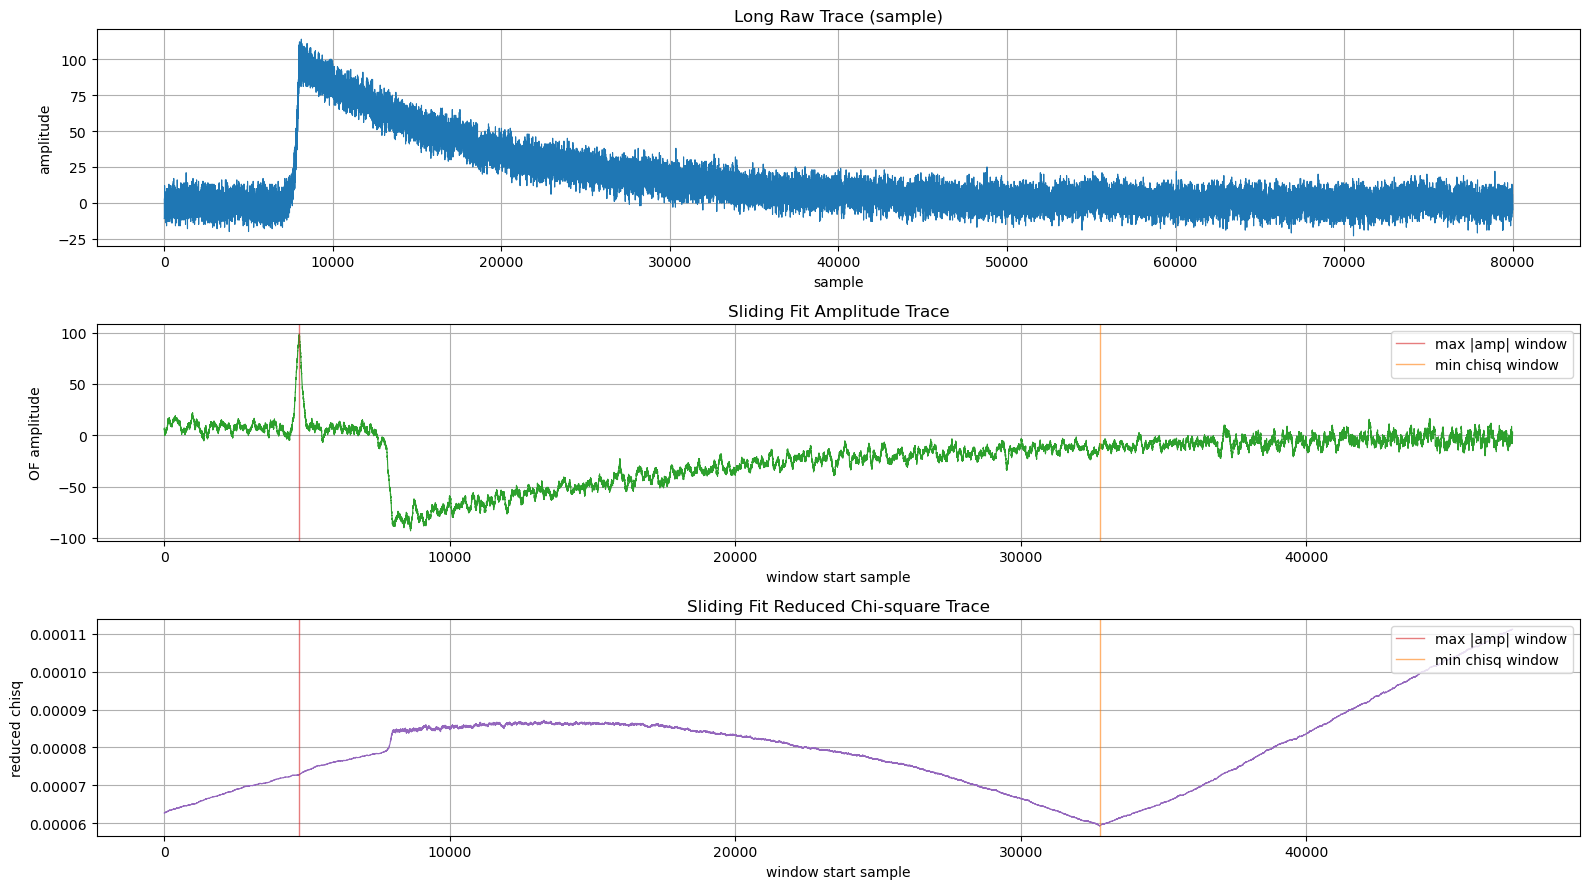

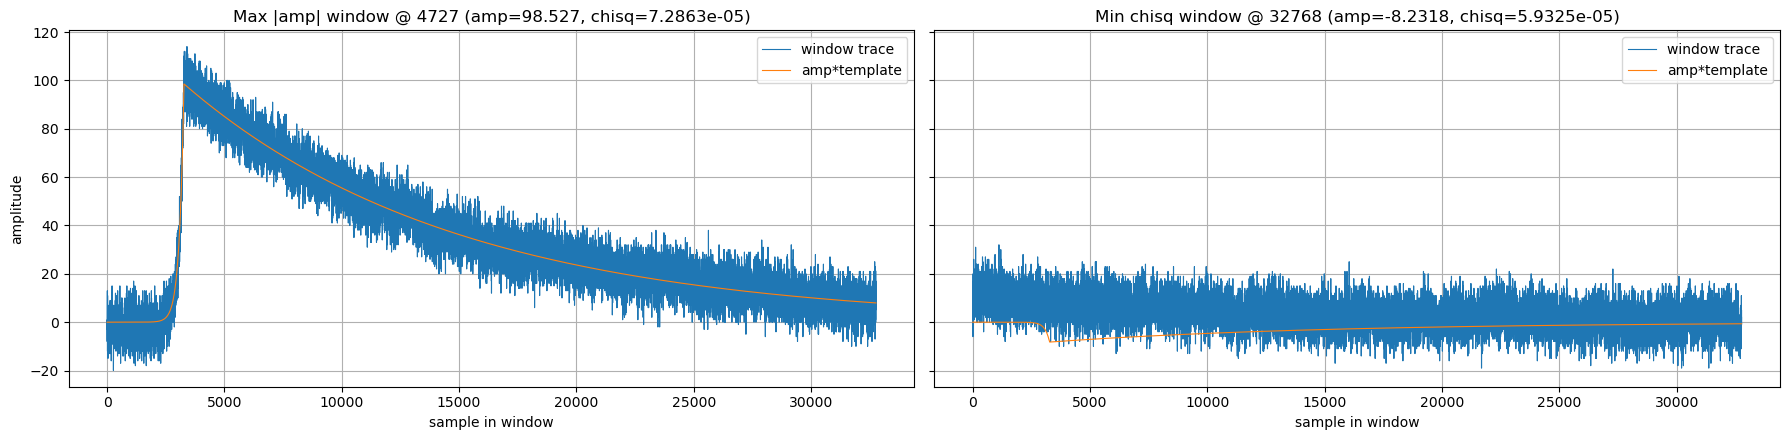

In [66]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=False)

axes[0].plot(long_trace, lw=0.8, color='tab:blue')
axes[0].set_title('Long Raw Trace (sample)')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('amplitude')

axes[1].plot(win_starts, slide_amp, lw=0.8, color='tab:green')
axes[1].axvline(start_max_amp, color='tab:red', alpha=0.6, lw=1.0, label='max |amp| window')
axes[1].axvline(start_min_chi, color='tab:orange', alpha=0.6, lw=1.0, label='min chisq window')
axes[1].set_title('Sliding Fit Amplitude Trace')
axes[1].set_xlabel('window start sample')
axes[1].set_ylabel('OF amplitude')
axes[1].legend(loc='upper right')

axes[2].plot(win_starts, slide_chi, lw=0.8, color='tab:purple')
axes[2].axvline(start_max_amp, color='tab:red', alpha=0.6, lw=1.0, label='max |amp| window')
axes[2].axvline(start_min_chi, color='tab:orange', alpha=0.6, lw=1.0, label='min chisq window')
axes[2].set_title('Sliding Fit Reduced Chi-square Trace')
axes[2].set_xlabel('window start sample')
axes[2].set_ylabel('reduced chisq')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

xw = np.arange(N)
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5), sharey=True)

axes[0].plot(xw, win_max_amp, lw=0.8, label='window trace')
axes[0].plot(xw, fit_max_amp, lw=0.8, label='amp*template')
axes[0].set_title(
    f'Max |amp| window @ {start_max_amp} (amp={slide_amp[idx_max_amp]:.5g}, chisq={slide_chi[idx_max_amp]:.5g})'
)
axes[0].set_xlabel('sample in window')
axes[0].set_ylabel('amplitude')
axes[0].legend(loc='upper right')

axes[1].plot(xw, win_min_chi, lw=0.8, label='window trace')
axes[1].plot(xw, fit_min_chi, lw=0.8, label='amp*template')
axes[1].set_title(
    f'Min chisq window @ {start_min_chi} (amp={slide_amp[idx_min_chi]:.5g}, chisq={slide_chi[idx_min_chi]:.5g})'
)
axes[1].set_xlabel('sample in window')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## Summary

- Registering OF needs `template`, one-sided `noise_psd`, and `sampling_frequency`.
- This tutorial uses UV template by default: `OF_tutorial/templates/UV_template.npy`.
- If UV template is stored as one-sided frequency-domain data, the notebook converts it to time domain via `irfft` (without extra amplitude renormalization).
- Short/long traces are read from `OF_tutorial/samples/` (`uv_shift_32768.npy`, `uv_noisy_80000.npy`).
- Noise PSD is loaded from `OF_tutorial/templates/noise_psd_xray.npy` when available; otherwise it is deterministically estimated from sample traces.
- The delay-domain "filtered trace" is a matched-filter response vs delay (correlation-like score), not a denoised waveform.
- For `fit_with_shift` visualization, check delay sign convention using residuals before interpreting overlays.
- Template mismatch can inflate reduced chi-square and weaken recovered amplitude; best-fit overlays and residuals make this visible.
- In long sliding fits, low chi-square can also come from near-flat (tiny-amplitude) windows, so use amplitude + waveform checks together.
